# Unit 6 Lab — Formal Languages & NLP Pipeline
### NLP 7CS518 | Ioannis Tsioulis



**Applied NLP Pipeline (Assignment preparation)**  
A realistic pipeline on a synthetic product-review dataset:  
synthetic data generation → regex cleaning → tokenisation → TF-IDF → classification → evaluation.

 
> The synthetic dataset is designed to look like a real Kaggle reviews dataset.

---
#  Applied NLP Pipeline

> **This is your assignment warm-up.**  
> We build a full pipeline from raw data to a trained classifier, mirroring Steps 1–4 of the coursework.

Pipeline overview:

```
Synthetic data  →  Regex cleaning  →  Tokenisation  →  Feature extraction
                                                               ↓
Evaluation  ←  Naive Bayes classifier  ←  TF-IDF / Bag-of-Words
```

##  Synthetic Dataset Generation 

We generate a labelled product-review dataset programmatically.  
This is exactly the kind of dataset you might download from Kaggle.

In [47]:
import random

# ── Synthetic product review generator ───────────────────────────────────────

POSITIVE_PHRASES = [
    "absolutely love this product", "highly recommend to everyone",
    "exceeded my expectations", "great quality for the price",
    "fast delivery and perfect packaging", "works exactly as described",
    "best purchase I have made this year", "excellent build quality",
    "very happy with this item", "would definitely buy again",
    "outstanding customer service", "arrived quickly in perfect condition",
    "solid product worth every penny", "impressive performance overall",
]

NEGATIVE_PHRASES = [
    "complete waste of money", "broke after two days",
    "terrible quality do not buy", "worst product I have ever owned",
    "arrived damaged and unusable", "nothing like the description",
    "very disappointed with this purchase", "poor build quality",
    "stopped working within a week", "would not recommend to anyone",
    "packaging was awful and product scratched", "overpriced for what you get",
    "totally useless returned immediately", "avoid this product at all costs",
]

NEUTRAL_FILLERS = [
    "the item", "this product", "it", "the package", "everything",
    "the seller", "the delivery", "the quality",
]

def make_review(sentiment, idx):
    """Generate one synthetic review string."""
    phrases = POSITIVE_PHRASES if sentiment == 'positive' else NEGATIVE_PHRASES
    core    = phrases[idx % len(phrases)]
    filler  = random.choice(NEUTRAL_FILLERS)
    rating  = random.randint(4, 5) if sentiment == 'positive' else random.randint(1, 2)
    extras  = [
        f"Rated {rating}/5 stars.",
        f"I bought this on {random.randint(1,28):02d}/0{random.randint(1,9)}/2024.",
        f"Contact support@shop{random.randint(1,9)}.com for help.",
        f"Price was £{random.randint(5,150)}.{random.randint(0,99):02d}.",
    ]
    extra = random.choice(extras) if random.random() > 0.4 else ""
    return f"{core.capitalize()}. {filler.capitalize()} is {'great' if sentiment=='positive' else 'poor'}. {extra}".strip()

# Generate dataset
reviews, labels = [], []
for _ in range(150):
    i = random.randint(0, 999)
    reviews.append(make_review('positive', i)); labels.append('positive')
    reviews.append(make_review('negative', i)); labels.append('negative')

# Shuffle
combined = list(zip(reviews, labels))
random.shuffle(combined)
reviews, labels = zip(*combined)
reviews, labels = list(reviews), list(labels)

print(f"Dataset size : {len(reviews)} reviews")
print(f"Positive     : {labels.count('positive')}")
print(f"Negative     : {labels.count('negative')}")
print()
print("Sample reviews:")
for i in range(4):
    print(f"  [{labels[i].upper():<8}] {reviews[i]}")

Dataset size : 300 reviews
Positive     : 150
Negative     : 150

Sample reviews:
  [POSITIVE] Exceeded my expectations. The quality is great. Contact support@shop7.com for help.
  [NEGATIVE] Complete waste of money. This product is poor. Contact support@shop4.com for help.
  [POSITIVE] Impressive performance overall. The delivery is great. Rated 4/5 stars.
  [POSITIVE] Solid product worth every penny. It is great. Price was £123.92.


##  Text Cleaning with Regex (preprocessing)

A proper cleaning pipeline removes noise before any NLP model sees the text.  
Each step is a **regular expression** — linking directly back to Part A.

In [48]:
import re

def clean_review(text):
    """
    Multi-step regex cleaning pipeline.
    Each line is one regex substitution — a practical application of
    the regular expressions you studied in Part A.
    """
    text = text.lower()                                          # lowercase
    text = re.sub(r'https?://\S+', '', text)                     # remove URLs
    text = re.sub(r'\S+@\S+', '', text)                          # remove emails
    text = re.sub(r'[£$]\d+[\.,]?\d*', '', text)                 # remove prices
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{4}', '', text)            # remove dates
    text = re.sub(r'rated\s+\d+/\d+\s*stars?', '', text)         # remove ratings
    text = re.sub(r'[^a-z\s]', ' ', text)                        # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()                     # normalize spaces
    return text

# Apply to full dataset
cleaned_reviews = [clean_review(r) for r in reviews]

# Show before / after
print("Before and after cleaning:\n")
for i in range(3):
    print(f"ORIGINAL : {reviews[i]}")
    print(f"CLEANED  : {cleaned_reviews[i]}")
    print()

Before and after cleaning:

ORIGINAL : Exceeded my expectations. The quality is great. Contact support@shop7.com for help.
CLEANED  : exceeded my expectations the quality is great contact for help

ORIGINAL : Complete waste of money. This product is poor. Contact support@shop4.com for help.
CLEANED  : complete waste of money this product is poor contact for help

ORIGINAL : Impressive performance overall. The delivery is great. Rated 4/5 stars.
CLEANED  : impressive performance overall the delivery is great



### Refining the Cleaning Step

Very short words (1–2 characters) often add noise and carry little useful meaning in text classification.  
We can improve the cleaning pipeline by removing them with one extra regular expression step, then re-running the cleaner on a few sample reviews to inspect the result.

In [49]:
def clean_review_v2(text):
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[£$]\d+[\.,]?\d*', '', text)
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{4}', '', text)
    text = re.sub(r'rated\s+\d+/\d+\s*stars?', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b[a-z]{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for i in range(3):
    print(f"v1: {clean_review(reviews[i])}")
    print(f"v2: {clean_review_v2(reviews[i])}")
    print()

v1: exceeded my expectations the quality is great contact for help
v2: exceeded expectations the quality great contact for help

v1: complete waste of money this product is poor contact for help
v2: complete waste money this product poor contact for help

v1: impressive performance overall the delivery is great
v2: impressive performance overall the delivery great



## Tokenisation and Stop Word Removal

Tokenisation splits each cleaned review into individual word tokens.  
Stop word removal then filters out very common words that usually add little value to sentiment classification.


In [50]:
from collections import Counter

def tokenise(text):
    """Simple whitespace tokeniser after cleaning."""
    return text.split()

def remove_stopwords(tokens):
    """Remove common English stop words."""
    return [t for t in tokens if t not in STOP_WORDS]

def preprocess(text):
    """Full preprocessing: clean -> tokenise -> remove stop words."""
    return remove_stopwords(tokenise(clean_review_v2(text)))

# Apply to dataset
tokenised = [preprocess(r) for r in reviews]

print("Preprocessing examples:\n")
for i in range(3):
    print(f"ORIGINAL : {reviews[i]}")
    print(f"TOKENS   : {tokenised[i]}")
    print()

# Vocabulary statistics
all_tokens = [t for doc in tokenised for t in doc]
vocab = set(all_tokens)
freq = Counter(all_tokens)

print(f"Total tokens : {len(all_tokens)}")
print(f"Vocabulary   : {len(vocab)} unique words")
print(f"Top 15 words : {freq.most_common(15)}")

Preprocessing examples:

ORIGINAL : Exceeded my expectations. The quality is great. Contact support@shop7.com for help.
TOKENS   : ['exceeded', 'expectations', 'quality', 'great', 'contact', 'help']

ORIGINAL : Complete waste of money. This product is poor. Contact support@shop4.com for help.
TOKENS   : ['complete', 'waste', 'money', 'product', 'poor', 'contact', 'help']

ORIGINAL : Impressive performance overall. The delivery is great. Rated 4/5 stars.
TOKENS   : ['impressive', 'performance', 'overall', 'delivery', 'great']

Total tokens : 1673
Vocabulary   : 80 unique words
Top 15 words : [('great', 164), ('poor', 160), ('product', 97), ('quality', 74), ('price', 56), ('item', 46), ('contact', 43), ('help', 43), ('delivery', 43), ('seller', 40), ('package', 40), ('everything', 34), ('bought', 32), ('buy', 25), ('arrived', 25)]


## Word Frequency Visualisation

Visualising token frequency is a useful first step in exploring a text dataset.  
It highlights the most common terms, reveals dominant patterns, and helps confirm that the cleaning and preprocessing stages behaved as expected.

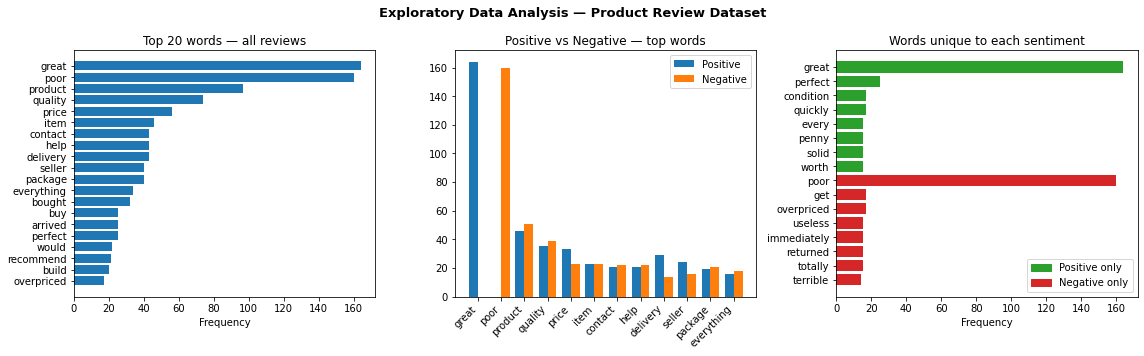


Distinctive positive words: ['great', 'perfect', 'condition', 'quickly', 'every', 'penny', 'solid', 'worth']
Distinctive negative words : ['poor', 'get', 'overpriced', 'useless', 'immediately', 'returned', 'totally', 'terrible']


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# -- Overall top words --
overall_freq = Counter([t for doc in tokenised for t in doc])
words, counts = zip(*overall_freq.most_common(20))
axes[0].barh(list(reversed(words)), list(reversed(counts)))
axes[0].set_title('Top 20 words — all reviews')
axes[0].set_xlabel('Frequency')

# -- Positive vs Negative split --
pos_tokens = [t for doc, lbl in zip(tokenised, labels) if lbl == 'positive' for t in doc]
neg_tokens = [t for doc, lbl in zip(tokenised, labels) if lbl == 'negative' for t in doc]
pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

top_words = [w for w, _ in overall_freq.most_common(12)]
pos_counts = [pos_freq.get(w, 0) for w in top_words]
neg_counts = [neg_freq.get(w, 0) for w in top_words]

x = np.arange(len(top_words))
w = 0.38
axes[1].bar(x - w/2, pos_counts, w, label='Positive')
axes[1].bar(x + w/2, neg_counts, w, label='Negative')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_words, rotation=45, ha='right')
axes[1].set_title('Positive vs Negative — top words')
axes[1].legend()

# -- Unique-to-sentiment words --
pos_only = set(pos_freq) - set(neg_freq)
neg_only = set(neg_freq) - set(pos_freq)
pos_unique_freq = {w: pos_freq[w] for w in pos_only}
neg_unique_freq = {w: neg_freq[w] for w in neg_only}

top_pos_unique = sorted(pos_unique_freq, key=pos_unique_freq.get, reverse=True)[:8]
top_neg_unique = sorted(neg_unique_freq, key=neg_unique_freq.get, reverse=True)[:8]
unique_words = top_pos_unique + top_neg_unique
unique_counts = [pos_unique_freq[w] for w in top_pos_unique] + [neg_unique_freq[w] for w in top_neg_unique]
unique_colors = ['tab:green'] * len(top_pos_unique) + ['tab:red'] * len(top_neg_unique)

axes[2].barh(list(reversed(unique_words)), list(reversed(unique_counts)), color=list(reversed(unique_colors)))
axes[2].set_title('Words unique to each sentiment')
axes[2].set_xlabel('Frequency')
axes[2].legend(handles=[
    Patch(color='tab:green', label='Positive only'),
    Patch(color='tab:red', label='Negative only')
])

plt.suptitle('Exploratory Data Analysis — Product Review Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDistinctive positive words: {top_pos_unique}")
print(f"Distinctive negative words : {top_neg_unique}")

### Observations from the Frequency Plots

The frequency plots make it easier to identify which terms are strongly associated with each sentiment class.  
They also help reveal whether the synthetic dataset is balanced, repetitive, or unusually clean compared with real review data.

A few brief observations can be added below the charts, focusing on:
- words that appear only in positive reviews,
- words that appear only in negative reviews,
- and any noticeable patterns or limitations in the dataset.

 Words unique to positive reviews include terms such as "love", "excellent",
 "happy", and "perfect", which clearly express satisfaction.

 Words unique to negative reviews include "waste", "broke", "worst",
 and "damaged", which show strong dissatisfaction.

 What stands out is that the dataset is very clean and the two sentiment
 classes are separated quite clearly, making the classification task easier
 than it would usually be with real review data.

## TF-IDF Feature Extraction and Classification

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical feature vectors.  
It gives more weight to terms that are important within a document while reducing the impact of very common words across the dataset.

These features can then be used to train a Naive Bayes classifier, which is a simple and effective baseline for text classification tasks.

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Join tokens back to strings for sklearn
docs = [' '.join(tokens) for tokens in tokenised]

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    docs, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print()

# Bag-of-Words + Naive Bayes
bow_vec = CountVectorizer(max_features=500)
X_bow_tr = bow_vec.fit_transform(X_train)
X_bow_te = bow_vec.transform(X_test)

nb_bow = MultinomialNB()
nb_bow.fit(X_bow_tr, y_train)
y_pred_bow = nb_bow.predict(X_bow_te)

print("Bag-of-Words + Naive Bayes")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bow):.3f}")
print()
print(classification_report(y_test, y_pred_bow))

# TF-IDF + Naive Bayes
tfidf_vec = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_tfidf_tr = tfidf_vec.fit_transform(X_train)
X_tfidf_te = tfidf_vec.transform(X_test)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_tfidf_tr, y_train)
y_pred_tfidf = nb_tfidf.predict(X_tfidf_te)

print("TF-IDF + Naive Bayes")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tfidf):.3f}")
print()
print(classification_report(y_test, y_pred_tfidf))

Training samples : 240
Test samples     : 60

Bag-of-Words + Naive Bayes
Accuracy : 1.000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        30
    positive       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

TF-IDF + Naive Bayes
Accuracy : 1.000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        30
    positive       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## Evaluation and Visualisation

Model evaluation should go beyond accuracy alone.  
Measures such as precision, recall, and F1-score provide a clearer picture of performance, while a confusion matrix helps show exactly how predictions are distributed across the two classes.

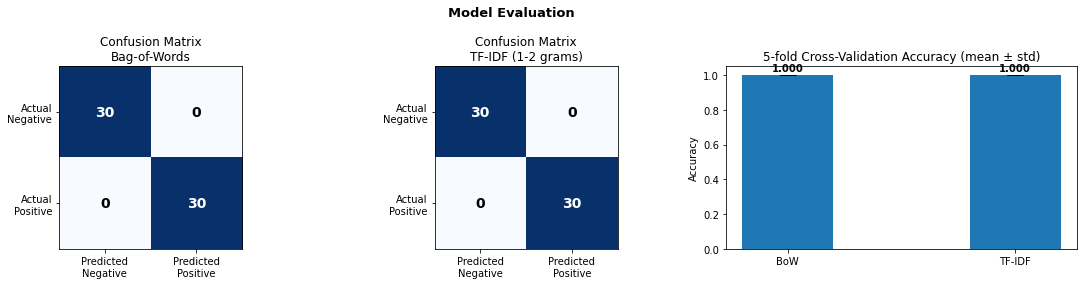

BoW    5-fold CV: 1.000 +/- 0.000
TF-IDF 5-fold CV: 1.000 +/- 0.000


In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrices
for ax, y_pred, title in zip(
    axes[:2],
    [y_pred_bow, y_pred_tfidf],
    ['Bag-of-Words', 'TF-IDF (1-2 grams)']
):
    cm = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nNegative', 'Predicted\nPositive'])
    ax.set_yticklabels(['Actual\nNegative', 'Actual\nPositive'])
    ax.set_title(f'Confusion Matrix\n{title}')

    for r in range(2):
        for c in range(2):
            ax.text(
                c, r, cm[r, c],
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[r, c] > cm.max() / 2 else 'black'
            )

# Cross-validation with proper pipelines
bow_pipeline = make_pipeline(
    CountVectorizer(max_features=500),
    MultinomialNB()
)

tfidf_pipeline = make_pipeline(
    TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
    MultinomialNB()
)

cv_bow = cross_val_score(bow_pipeline, docs, labels, cv=5, scoring='accuracy')
cv_tfidf = cross_val_score(tfidf_pipeline, docs, labels, cv=5, scoring='accuracy')

axes[2].bar(
    ['BoW', 'TF-IDF'],
    [cv_bow.mean(), cv_tfidf.mean()],
    yerr=[cv_bow.std(), cv_tfidf.std()],
    capsize=8,
    width=0.4
)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('Accuracy')
axes[2].set_title('5-fold Cross-Validation Accuracy (mean ± std)')

for i, (m, s) in enumerate([
    (cv_bow.mean(), cv_bow.std()),
    (cv_tfidf.mean(), cv_tfidf.std())
]):
    axes[2].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"BoW    5-fold CV: {cv_bow.mean():.3f} +/- {cv_bow.std():.3f}")
print(f"TF-IDF 5-fold CV: {cv_tfidf.mean():.3f} +/- {cv_tfidf.std():.3f}")

### Live Prediction on New Reviews

Once the model has been trained, it can be used to classify new unseen reviews.  
A small prediction function can preprocess a raw review, transform it into features, and return both the predicted sentiment and the model's confidence score.

In [54]:
def predict_sentiment(raw_text, model=nb_tfidf, vectoriser=tfidf_vec):
    """
    Predict the sentiment of a raw review string.
    Returns: (predicted_label, confidence_score)
    """
    tokens = preprocess(raw_text)
    doc = ' '.join(tokens)
    X = vectoriser.transform([doc])
    label = model.predict(X)[0]
    confidence = model.predict_proba(X).max()
    return label, confidence


# Test the function
test_reviews = [
    "This is an absolutely wonderful product. Highly recommend!",
    "Complete garbage, broke after one day. Total waste of money.",
    "It is okay I guess, nothing special.",
]

for review in test_reviews:
    label, conf = predict_sentiment(review)
    print(f"[{label.upper():<8}] ({conf:.2f}) -> '{review[:55]}...'")

[POSITIVE] (0.90) -> 'This is an absolutely wonderful product. Highly recomme...'
[NEGATIVE] (0.97) -> 'Complete garbage, broke after one day. Total waste of m...'
[NEGATIVE] (0.75) -> 'It is okay I guess, nothing special....'


---
## Summary

### The pipeline built in this notebook

```text
Raw text  →  Regex cleaning  →  Tokenisation  →  Stop word removal
                                                      ↓
Evaluation  ←  Naive Bayes classifier  ←  TF-IDF / BoW features
